<a href="https://colab.research.google.com/github/St1CkBSPL/PF174712/blob/main/Dane_i_przetwarzanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Moduł 1: Dane i przetwarzanie wstępne

## Klasyfikacja tematyczna krótkich tekstów w języku polskim

**Autor:** Kacper Mederski

**Opis:** Projekt realizuje kategoryzację krótkich form tekstowych w języku polskim, przypisując im dokładnie jedną z ośmiu predefiniowanych kategorii tematycznych. Porównujemy podejście klasyczne (TF-IDF + SVM) z podejściem opartym na Transformerach (HerBERT).

**Źródło danych:** zbiór danych sdadas/8tags, pobrany za pomocą biblioteki Hugging Face Datasets. Zbiór ten składa się z krótkich tekstów (nagłówków oraz wpisów internetowych) ręcznie oznakowanych przez ekspertów.

Przypisane kategorie w bazie danych:

0: film

1: historia

2: jedzenie

3: medycyna

4: motoryzacja

5: praca

6: sport

7: technologia

W tym module:
1. Pobieramy i ładujemy dane
2. Przeprowadzamy eksploracyjną analizę danych (EDA)
3. Wykonujemy przetwarzanie wstępne tekstu
4. Dzielimy dane na zbiory treningowy, walidacyjny i testowy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install datasets pandas matplotlib seaborn scikit-learn spacy wordcloud
!python -m spacy download pl_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 98.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/40001 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4372 [00:00<?, ? examples/s]

Podgląd danych:
                                            sentence  label
0  Nie żyje znany reżyser, twórca "Chłopaków z są...      0
1  Konserwacja kriogeniczna metodą na życie wiecz...      7
2                   Eurostat podał wskaźnik wakatów.      5
3        Jak więc ograniczyć cukier w naszej diecie?      2
4  Nowe obowiązki dla diagnostów w sprawie liczni...      7


/tmp/ipykernel_2863/2584798169.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


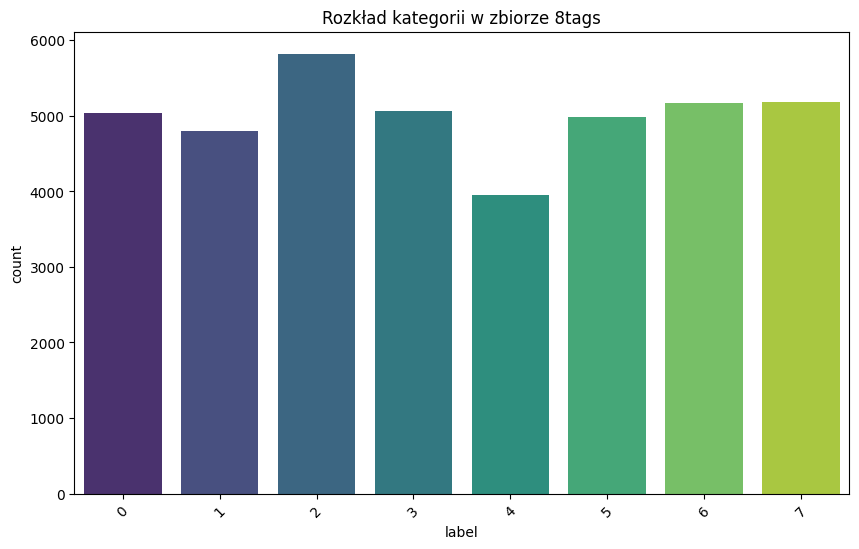


Średnia długość tekstu: 11.50 słów


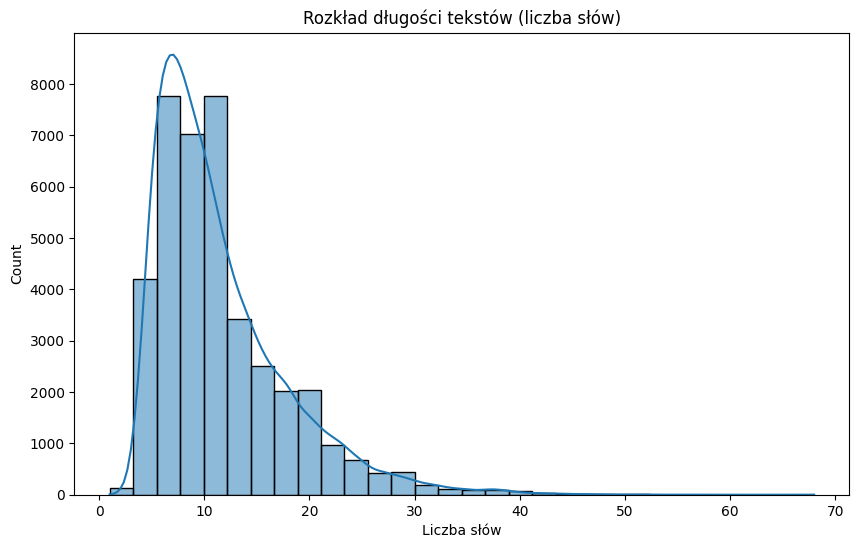

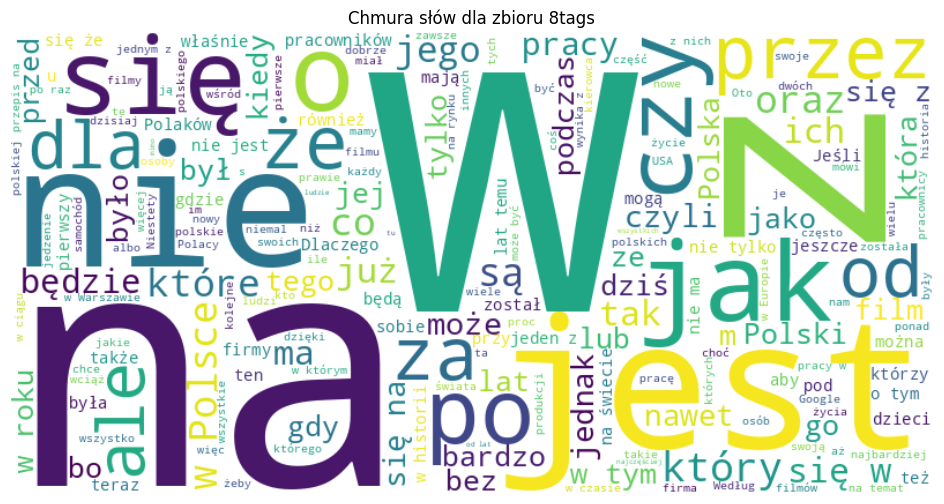

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import spacy
import re

# Ładowanie zbioru danych
dataset = load_dataset("sdadas/8tags")
df = pd.DataFrame(dataset['train'])

# Wyświetlenie pierwszych kilku wierszy
print("Podgląd danych:")
print(df.head())

# Sprawdzenie liczebności klas
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Rozkład kategorii w zbiorze 8tags')
plt.xticks(rotation=45)
plt.show()

# Analiza długości tekstów
df['text_len'] = df['sentence'].apply(lambda x: len(str(x).split()))
print(f"\nŚrednia długość tekstu: {df['text_len'].mean():.2f} słów")

plt.figure(figsize=(10, 6))
sns.histplot(df['text_len'], bins=30, kde=True)
plt.title('Rozkład długości tekstów (liczba słów)')
plt.xlabel('Liczba słów')
plt.show()

# Chmura najpopularniejszych słów w korpusie
all_text = " ".join(df['sentence'].astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Chmura słów dla zbioru 8tags')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Załadowanie polskiego modelu spaCy
nlp = spacy.load("pl_core_news_sm")

def clean_text_advanced(text):
    # Usunięcie URL-i
    text = re.sub(r'http\S+|www\S+|https\S+', '', str(text), flags=re.MULTILINE)
    text = text.strip()
    doc = nlp(text)

    # Zatrzymujemy tylko te tokeny, które nie są znakami interpunkcyjnymi, spacjami ani stopwordami
    cleaned_tokens = [
        token.lemma_.lower() for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]

    return " ".join(cleaned_tokens)

print("Przetwarzanie tekstu:")
df = df.rename(columns={'sentence': 'text'})

# Stworzenie nowej kolumny ze znormalizowanym tekstem dla klasyfikatora TF-IDF + SVM
df['text_clean'] = df['text'].apply(clean_text_advanced)
print("Przetwarzanie zakończone.")

# Podział na zbiory: Treningowy, Walidacyjny i Testowy
# Najpierw wydzielamy test (20%)
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Z pozostałych 80% wydzielamy walidacyjny (10% całości, czyli 12.5% z 80%)
train_df, val_df = train_test_split(train_val_df, test_size=0.125, random_state=42, stratify=train_val_df['label'])

print(f"\nWielkość zbiorów:\nTreningowy: {len(train_df)}\nWalidacyjny: {len(val_df)}\nTestowy: {len(test_df)}")

Przetwarzanie tekstu:
Przetwarzanie zakończone.

Wielkość zbiorów:
Treningowy: 28000
Walidacyjny: 4000
Testowy: 8001


In [ ]:
# Zapis przetworzonych danych do zewnętrznych plików CSV
train_df.to_csv("/content/drive/MyDrive/train.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/val.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/test.csv", index=False)

print("Dane zapisane do plików: train.csv, val.csv, test.csv")
print("\nStruktura najważniejszych kolumn w wygenerowanych plikach:")
print("  'text'       - oryginalny tekst (dla modelu językowego HerBERT)")
print("  'text_clean' - wyczyszczony, zlematyzowany tekst (dla podejścia klasycznego TF-IDF)")
print("  'label'      - unikalna etykieta klasy (0-7)")

Dane zapisane do plików: train.csv, val.csv, test.csv

Struktura najważniejszych kolumn w wygenerowanych plikach:
  'text'       - oryginalny tekst (dla modelu językowego HerBERT)
  'text_clean' - wyczyszczony, zlematyzowany tekst (dla podejścia klasycznego TF-IDF)
  'label'      - unikalna etykieta klasy (0-7)
